In [1]:
# %%
from pathlib import Path
import pandas as pd

data_round = 2024

# load from raw data, where we have timing information
RAW_DIR = Path("/Users/jheitz/git/luha-prolific-study/data2026/raw") if data_round == 2026 else Path("/Users/jheitz/git/luha-prolific-study/data/raw")
TABLES = ["study_submissions", "status_changes"]


def merge(table):
    files = sorted(RAW_DIR.glob(f"*/database/{table}.csv"))
    print(f"\n=== {table}: {len(files)} files ===")

    frames = []
    for i, path in enumerate(files):
        # all as text so ids / timestamps round-trip unchanged
        df = pd.read_csv(path, dtype=str, keep_default_na=False, na_filter=False)
        df["_order"] = i  # tie-break: later folder wins
        print(f"  {path.parent.parent.name:<40} {len(df):>8} rows")
        frames.append(df)

    df = pd.concat(frames, ignore_index=True, sort=False).fillna("")
    df["_ts"] = pd.to_datetime(df["updated_at"], errors="coerce", utc=True, format="mixed")

    # ids whose duplicate rows actually disagree -- the ones worth looking at
    cols = [c for c in df.columns if not c.startswith("_")]
    dupes = df.loc[df.duplicated("id", keep=False), "id"].unique()
    bad = [i for i in dupes if len(df.loc[df["id"] == i, cols].drop_duplicates()) > 1]
    print(f"  {len(dupes)} duplicated ids, {len(bad)} of them disagree: {bad[:10]}")
    if df["_ts"].isna().any():
        print(f"  WARNING: {df['_ts'].isna().sum()} rows with unparseable updated_at (they lose)")

    # latest updated_at wins; NaT sorts first so it never wins over a real timestamp
    df = df.sort_values(["_ts", "_order"], kind="mergesort", na_position="first")
    out = df.drop_duplicates("id", keep="last").drop(columns=["_ts", "_order"])
    out = out.sort_values("id", key=lambda s: pd.to_numeric(s, errors="coerce").fillna(-1), kind="mergesort")

    print(f"  {len(df)} rows in -> {len(out)} rows out")
    return out.reset_index(drop=True)


study_submissions = merge("study_submissions")
status_changes = merge("status_changes")
acs_tokens = merge("acs_tokens")



=== study_submissions: 23 files ===
  2024-01-11-Test1                               40 rows
  2024-04-05-Test2                               37 rows
  2024-04-19-Test3                               69 rows
  2024-04-26-Round4                             132 rows
  2024-05-11-Round5_UK                          195 rows
  2024-05-14-Round6_US                          262 rows
  2024-05-16-Round7_UK                          321 rows
  2024-05-26-Round8_US                          447 rows
  2024-05-26-Round9_UK                          445 rows
  2024-05-29-Round10_US                         559 rows
  2024-05-30-Round11_UK                         567 rows
  2024-06-01-Round12_US                         687 rows
  2024-06-01-Round13_UK                         687 rows
  2024-06-03-Round14_US                         806 rows
  2024-06-03-Round15_UK                         806 rows
  2024-06-05-Round16_US                         935 rows
  2024-06-05-Round17_UK                         935

In [2]:
def merge_acs(filename="ACS_RESULTS_PROCESSED.xlsx"):
    files = sorted(RAW_DIR.glob(f"*/{filename}"))
    print(f"\n=== {filename}: {len(files)} files ===")

    frames = []
    for i, path in enumerate(files):
        # all as text so ids / timestamps round-trip unchanged
        df = pd.read_excel(path, dtype=str, keep_default_na=False, na_filter=False)
        df["_order"] = i  # tie-break: later folder wins
        print(f"  {path.parent.name:<40} {len(df):>8} rows")

        df = df.drop(columns=[c for c in df.columns if 'Unnamed' in c])
        frames.append(df)

    df = pd.concat(frames, ignore_index=True, sort=False).fillna("")

    def parse_hhmmfrac(t):
        if pd.isna(t):
            return pd.NaT
        try:
            hh, mm_frac = str(t).split(":")
            total_seconds = int(hh) * 3600 + float(mm_frac) * 60
            return pd.to_timedelta(total_seconds, unit="s")
        except (ValueError, AttributeError):
            return pd.NaT

    df["_date_end"] = pd.to_datetime(df["O_34_date"], format="%d%m%Y", errors="coerce")
    df["_acs_end"] = df["_date_end"] + df["O_34_time_s"].apply(parse_hhmmfrac)

    df["_date_start"] = pd.to_datetime(df["O_1_date"], format="%d%m%Y", errors="coerce")
    df["_acs_start"] = df["_date_start"] + df["O_1_time_s"].apply(parse_hhmmfrac)

    df['_acs_duration'] = df["_acs_end"] - df["_acs_start"]

    df['_ts'] = df["_acs_end"]

    # ids whose duplicate rows actually disagree -- the ones worth looking at
    cols = [c for c in df.columns if not c.startswith("_")]
    dupes = df.loc[df.duplicated("O_token", keep=False), "O_token"].unique()
    bad = [i for i in dupes if len(df.loc[df["O_token"] == i, cols].drop_duplicates()) > 1]
    print(f"  {len(dupes)} duplicated O_tokens, {len(bad)} of them disagree: {bad[:10]}")
    if df["_ts"].isna().any():
        print(f"  WARNING: {df['_ts'].isna().sum()} rows with unparseable updated_at (they lose)")

    # latest _ts wins; NaT sorts first so it never wins over a real timestamp
    df = df.sort_values(["_ts", "_order"], kind="mergesort", na_position="first")
    out = df.drop_duplicates("O_token", keep="last").drop(columns=["_ts", "_order"])
    out = out.sort_values("O_token", key=lambda s: pd.to_numeric(s, errors="coerce").fillna(-1), kind="mergesort")


    print(f"  {len(df)} rows in -> {len(out)} rows out")
    return out.reset_index(drop=True)

acs_data = merge_acs()
acs_data


=== ACS_RESULTS_PROCESSED.xlsx: 23 files ===
  2024-01-11-Test1                               11 rows
  2024-04-05-Test2                               10 rows
  2024-04-19-Test3                               20 rows
  2024-04-26-Round4                              52 rows
  2024-05-11-Round5_UK                           54 rows
  2024-05-14-Round6_US                           54 rows
  2024-05-16-Round7_UK                           51 rows
  2024-05-26-Round8_US                          153 rows
  2024-05-26-Round9_UK                          153 rows
  2024-05-29-Round10_US                          51 rows
  2024-05-30-Round11_UK                          50 rows
  2024-06-01-Round12_US                         106 rows
  2024-06-01-Round13_UK                         106 rows
  2024-06-03-Round14_US                         101 rows
  2024-06-03-Round15_UK                         135 rows
  2024-06-05-Round16_US                         108 rows
  2024-06-05-Round17_UK                   

,O_testbattery,O_token,O_1_message,O_1_element_code,O_1_welcome_message,O_1_date,O_1_time_s,O_1_time_e,O_1_time_t,O_2_SOUNDTEST,...,O_35_VIDEO_end_OR_LS,O_35_date,O_35_time_s,O_35_time_e,O_35_time_t,_date_end,_acs_end,_date_start,_acs_start,_acs_duration
0,luha,0077UKherkx,message,3872,message-welcome,11052024,11:29.41,11:29.45,4612,soundtest,...,,,,,,NaT,NaT,2024-05-11,2024-05-11 11:29:24.600,NaT
1,luha,0087UKzknlp,message,3852,message-welcome,11052024,11:45.32,11:45.36,3696,soundtest,...,,,,,,NaT,NaT,2024-05-11,2024-05-11 11:45:19.200,NaT
2,luha,0094UKiqmhq,message,3872,message-welcome,11052024,12:01.46,12:01.48,2120,,...,,,,,,NaT,NaT,2024-05-11,2024-05-11 12:01:27.600,NaT
3,luha,0095UKnosqs,message,7151,message-welcome,11052024,12:01.18,12:01.25,7155,soundtest,...,,,,,,NaT,NaT,2024-05-11,2024-05-11 12:01:10.800,NaT
4,luha,0059USlmjtq,message,3852,message-welcome,14052024,18:30.05,18:30.10,5808,soundtest,...,,,,,,NaT,NaT,2024-05-14,2024-05-14 18:30:03.000,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1080,luha,0523USgcqaa,message,33319,message-welcome,1072024,20:42.40,20:42.51,10695,soundtest,...,video,1072024,22:27.33,22:28.33,60239,2024-07-10,2024-07-10 22:26:21.600,2024-07-10,2024-07-10 20:42:24.000,0 days 01:43:57.600000
1081,luha,0524USsycjc,message,31615,message-welcome,1072024,21:28.50,21:28.54,4118,soundtest,...,video,1072024,22:32.05,22:32.23,18294,2024-07-10,2024-07-10 22:31:23.400,2024-07-10,2024-07-10 21:28:30.000,0 days 01:02:53.400000
1082,luha,0525USeuekj,message,9910,message-welcome,1072024,22:49.34,22:49.39,5556,soundtest,...,video,2072024,00:12.14,00:12.40,25241,2024-07-20,2024-07-20 00:11:13.800,2024-07-10,2024-07-10 22:49:20.400,9 days 01:21:53.400000
1083,luha,0526USiivzo,message,37704,message-welcome,2072024,01:20.39,01:20.46,6967,soundtest,...,video,2072024,03:17.05,03:17.25,20111,2024-07-20,2024-07-20 03:16:09.600,2024-07-20,2024-07-20 01:20:23.400,0 days 01:55:46.200000


In [6]:
#study_submissions

In [7]:
#status_changes

In [8]:
from data_analysis.dataloader.dataloader import Luha2026DataLoader, Luha2024DataLoader
from config.config import Config

config2024 = Config.from_dict({'config_data':{'split': 'full'}, 'config_model': {'cv_splits': 1}})

dataloader = Luha2026DataLoader() if data_round == 2026 else Luha2024DataLoader(config=config2024)
data = dataloader.load_data()
study_submission_ids_in_data = set(data.sample_names)

/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/webrtcvad.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


No task specified, loading pictureDescription
No consent_filter specified (consent for further data use), loading all participants
Initializing dataloader Luha 2024 Dataloader (transcript_version google, task pictureDescription) Split full
Loading data using dataloader Luha 2024 Dataloader
Combining cookieTheft and picnicScene to get pictureDescription... ... done.
Standardizing theory factor scores to zero mean and unit variance. This makes comparison of certain evaluation metrics, beta coefficients etc. more interpretable.


In [9]:
study_submissions = study_submissions[study_submissions["id"].isin(study_submission_ids_in_data)]
#study_submissions


In [10]:

P = "prolific_id"   # <- participant column in study_submission; check sub.columns

status_changes["timestamp"] = pd.to_datetime(status_changes["timestamp"], errors="coerce")

# duration of a status = time until the next status change *within the same submission*
status_changes = status_changes.sort_values(["study_submission_id", "timestamp"], kind="mergesort")
status_changes["duration_min"] = (
    status_changes.groupby("study_submission_id")["timestamp"].shift(-1) - status_changes["timestamp"]
).dt.total_seconds() / 60

sc = status_changes.merge(
    study_submissions[["id", P]].rename(columns={"id": "study_submission_id"}),
    on="study_submission_id", how="left", validate="many_to_one",
)

print("no successor (last status per submission):", sc["duration_min"].isna().sum())
print("negative durations:", (sc["duration_min"] < 0).sum())
print("unmatched submission_ids:", sc[P].isna().sum())

d = sc.dropna(subset=["duration_min"])

# per participant: total time spent in each status
per_participant = d.groupby([P, "new_status"])["duration_min"].sum().reset_index()

# mean / std across participants
summary = (per_participant.groupby("new_status")["duration_min"]
           .agg(n="count", mean="mean", std="std", median="median", min='min', max='max')
           .sort_values("mean", ascending=False))
summary

no successor (last status per submission): 1215
negative durations: 0
unmatched submission_ids: 1875


,n,mean,std,median,min,max
new_status,,,,,,
back-to-prolific,24,6647.338889,19436.877486,1598.008333,0.000000,96830.100000
end,958,79.545320,176.294546,66.400000,2.333333,4066.466667
rey-figure-intro,911,57.861544,1432.709515,1.100000,0.033333,43180.966667
picture-description,1002,26.561727,735.049285,1.466667,0.250000,23259.983333
feedback,822,23.106306,424.581705,0.166667,0.016667,10080.766667
phonemic-fluency,998,22.960354,501.203154,1.483333,1.066667,14107.883333
naming,992,20.061425,577.291404,1.133333,0.516667,18182.466667
journalling,999,4.563347,65.046755,1.700000,0.216667,2006.200000
technical-check,999,2.535819,51.403031,0.433333,0.150000,1622.266667


In [11]:
summary.query('new_status != "back-to-prolific"').sum()

n          12680.000000
mean         247.228582
std         4036.194213
median        80.275000
min            7.550000
max       118752.133333
dtype: float64

In [12]:
import matplotlib.pyplot as plt

GROUPS = {
    "acs":                  "acs",
    "phonemic-fluency":     "standardized_language_tasks",
    "semantic-fluency":     "standardized_language_tasks",
    "naming":               "standardized_language_tasks",
    "journalling":          "spontaneous_speech",
    "picture-description":  "spontaneous_speech",
    "picture-description2": "spontaneous_speech",
    'sdc': 'demographics',
    'demographics': 'demographics',
    'iadl': 'demographics',

}
ORDER = ["acs", "standardized_language_tasks", "spontaneous_speech", 'demographics']

g = d.copy()
g["task_group"] = g["new_status"].map(GROUPS)
print("statuses dropped:", sorted(set(d["new_status"]) - set(GROUPS)))
g = g.dropna(subset=["task_group"])

# one value per participant per group: total minutes across that group's statuses
pp = (g.groupby([P, "task_group"])["duration_min"].sum()
        .rename("minutes").reset_index())

stats = (pp.groupby("task_group")["minutes"]
           .agg(n="count", mean="mean", std="std", median="median",
                q25=lambda s: s.quantile(.25), q75=lambda s: s.quantile(.75),
                min="min", max="max")
           .reindex(ORDER).round(2))
print(stats)

statuses dropped: ['back-to-prolific', 'consent', 'end', 'feedback', 'journaling', 'picture-naming', 'rey-figure', 'rey-figure-intro', 'technical-check']
                                n   mean     std  median   q25   q75   min  \
task_group                                                                   
acs                           999   2.27   52.44    0.23  0.17  0.35  0.02   
standardized_language_tasks   999  44.36  762.35    4.00  3.64  4.60  2.37   
spontaneous_speech           1002  33.31  738.05    4.78  4.13  5.92  1.63   
demographics                 1000   1.67    0.96    1.46  1.17  1.90  0.52   

                                  max  
task_group                             
acs                           1652.13  
standardized_language_tasks  18185.47  
spontaneous_speech           23266.25  
demographics                    12.72  


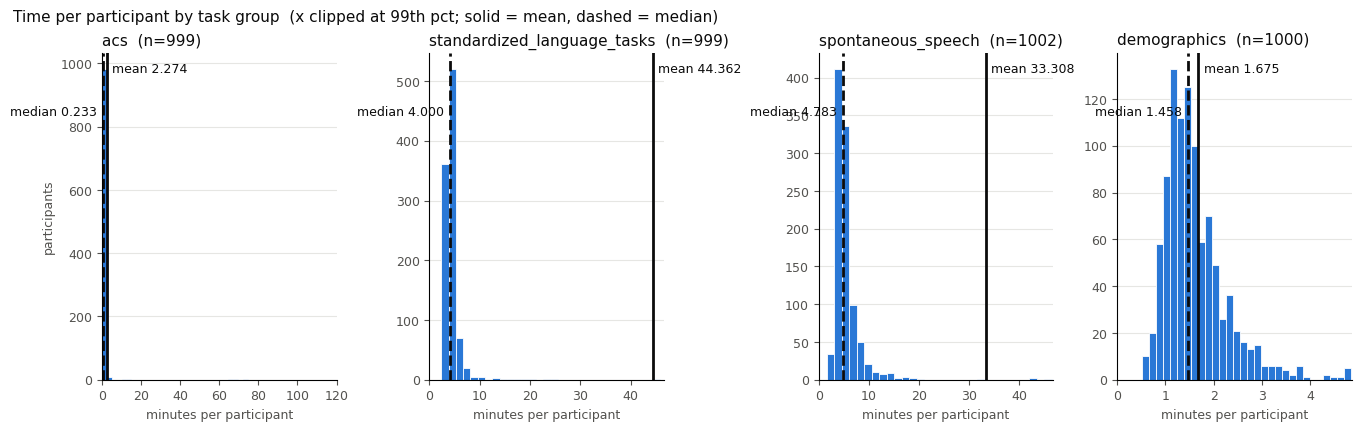

In [13]:
BAR, INK, MUTED = "#2a78d6", "#0b0b0b", "#52514e"
fig, axes = plt.subplots(1, len(ORDER), figsize=(13.5, 4.2), constrained_layout=True)

for ax, grp in zip(axes, ORDER):
    v = pp.loc[pp["task_group"] == grp, "minutes"]
    mean, med = v.mean(), v.median()
    hi = max(v.quantile(0.99), mean * 1.05)      # clip the tail, keep the mean on screen
    hi = 120 if grp == 'acs' else hi

    ax.hist(v[v <= hi], bins=30, color=BAR, edgecolor="white", linewidth=0.6)
    ax.axvline(mean, color=INK, lw=2, ls="-")
    ax.axvline(med,  color=INK, lw=2, ls="--")

    top = ax.get_ylim()[1]
    ax.annotate(f"mean {mean:.3f}", (mean, top * 0.97), color=INK, fontsize=9,
                ha="left", va="top", xytext=(4, 0), textcoords="offset points")
    ax.annotate(f"median {med:.3f}", (med, top * 0.84), color=INK, fontsize=9,
                ha="right", va="top", xytext=(-4, 0), textcoords="offset points")

    ax.set_xlim(0, hi)
    ax.set_title(f"{grp}  (n={len(v)})", fontsize=11, color=INK, loc="left")
    ax.set_xlabel("minutes per participant", fontsize=9, color=MUTED)
    ax.grid(axis="y", color="#e6e6e3", lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(colors=MUTED, labelsize=9)

#axes[0].set_xlim(0, 1100)

axes[0].set_ylabel("participants", fontsize=9, color=MUTED)
fig.suptitle("Time per participant by task group  "
             "(x clipped at 99th pct; solid = mean, dashed = median)",
             fontsize=11, color=INK, ha="left", x=0.005)
plt.show()

In [14]:
for grp in ORDER:
    v = pp.loc[pp["task_group"] == grp, "minutes"]
    print(grp, "Median: {:.1f} minutes, IQR: {:.1f} - {:.1f} minutes".format(v.median(), v.quantile(0.25), v.quantile(0.75)))

acs Median: 0.2 minutes, IQR: 0.2 - 0.3 minutes
standardized_language_tasks Median: 4.0 minutes, IQR: 3.6 - 4.6 minutes
spontaneous_speech Median: 4.8 minutes, IQR: 4.1 - 5.9 minutes
demographics Median: 1.5 minutes, IQR: 1.2 - 1.9 minutes


In [17]:
# acs is invalid, needs to be calculated from the ACS data directly

study_submissions_with_acs_token = study_submissions.merge(acs_tokens, left_on="acs_token_id", right_on="id", how="left")
acs_data_filtered = acs_data[acs_data["O_token"].isin(study_submissions_with_acs_token["token"])]
#acs_data_filtered


In [18]:
duration_minutes = acs_data_filtered['_acs_duration'].dropna().dt.total_seconds() / 60
duration_minutes = duration_minutes[(duration_minutes > 0) & (duration_minutes < 180)]

"ACS: Median: {:.1f} minutes, IQR: {:.1f} - {:.1f} minutes".format(duration_minutes.median(), duration_minutes.quantile(0.25), duration_minutes.quantile(0.75))

'ACS: Median: 65.1 minutes, IQR: 60.4 - 72.2 minutes'